# Домашнє завдання: Прогнозування кредитного ризику

## Мета завдання
Застосувати знання з лекції для побудови моделі логістичної регресії, що прогнозує ймовірність дефолту за кредитом, іншими словами, що людина не поверне кредит. Ви пройдете весь цикл: від дослідницького аналізу до оцінки якості класифікаційної моделі.

## Опис датасету
**Credit Risk Dataset** містить інформацію про 32,000+ позичальників з такими параметрами:
- **person_age**: Вік позичальника
- **person_income**: Річний дохід
- **person_home_ownership**: Тип володіння житлом
- **person_emp_length**: Стаж роботи (в роках)
- **loan_intent**: Мета кредиту
- **loan_grade**: Кредитний рейтинг (A - кращий, F - гірший)
- **loan_amnt**: Сума кредиту
- **loan_int_rate**: Процентна ставка
- **loan_status**: Статус кредиту (0 = сплачено, 1 = дефолт) - **цільова змінна**
- **loan_percent_income**: Відношення кредиту до доходу
- **cb_person_default_on_file**: Історія дефолтів (Y/N)
- **cb_person_cred_hist_length**: Довжина кредитної історії

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `credit_risk_dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (кількість записів, типи колонок)
5. Перевірте розподіл цільової змінної (відсотк даних для кожного класу)

Дайте висновок, це задача збалансованої чи незбалансованої класифікації.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option('display.max_columns', None)

C:\Users\viver\AppData\Local\Temp\ipykernel_6816\3052747956.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# завантажуємо
df = pd.read_csv("../data/credit_risk_dataset.csv")


# інфо
print(f"Розмір: {df.shape}")
print(f"Кількість позичальників: {df.shape[0]:,}")
print(f"Кількість ознак: {df.shape[1]}")


Розмір: (32581, 12)
Кількість позичальників: 32,581
Кількість ознак: 12


In [3]:
# перші 5рядків
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
# типи даних
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
# р-л цільової змінної

loan_status_distribution = df["loan_status"].value_counts()
loan_status_percent = df["loan_status"].value_counts(normalize=True) * 100

loan_status_percent

loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64

перед нами задача незбалансованої класифікації (78% проти 22%). Більшість позичальників повертають позики (78%).


---

## Завдання 2: Дослідницький аналіз даних (EDA) (4 бали)

**Що потрібно зробити:**
1. Обчисліть відсоток пропущених значень в колонках. За наявності пропущених значень - заповніть їх медіаною для числових колонок і найбільш частим значеннмя для категоріальних.
2. Проаналізуйте розподіл числових змінних.
3. Знайдіть та обробіть викиди в колонці person_income з допомогою [Interquartile range](https://uk.wikipedia.org/wiki/%D0%9C%D1%96%D0%B6%D0%BA%D0%B2%D0%B0%D1%80%D1%82%D0%B8%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D1%80%D0%BE%D0%B7%D0%BC%D0%B0%D1%85).
4. Проаналізуйте категоріальні змінні відносно цільової та частоту зустрічання різних значень в них.
5. Візуалізуйте взаємозв'язок ознак з цільовою змінною.


In [6]:
# пропущені значення

missing = df.isnull().sum()
missing[missing > 0]

person_emp_length     895
loan_int_rate        3116
dtype: int64

In [7]:
# статистика числових змінних

df.select_dtypes("number").describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [8]:
# заповнення пропусків медіаною
df.fillna(df.median(numeric_only=True), inplace=True)

In [9]:
missing = df.isnull().sum()
missing

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

array([[<Axes: title={'center': 'person_age'}>,
        <Axes: title={'center': 'person_income'}>,
        <Axes: title={'center': 'person_emp_length'}>],
       [<Axes: title={'center': 'loan_amnt'}>,
        <Axes: title={'center': 'loan_int_rate'}>,
        <Axes: title={'center': 'loan_status'}>],
       [<Axes: title={'center': 'loan_percent_income'}>,
        <Axes: title={'center': 'cb_person_cred_hist_length'}>, <Axes: >]],
      dtype=object)

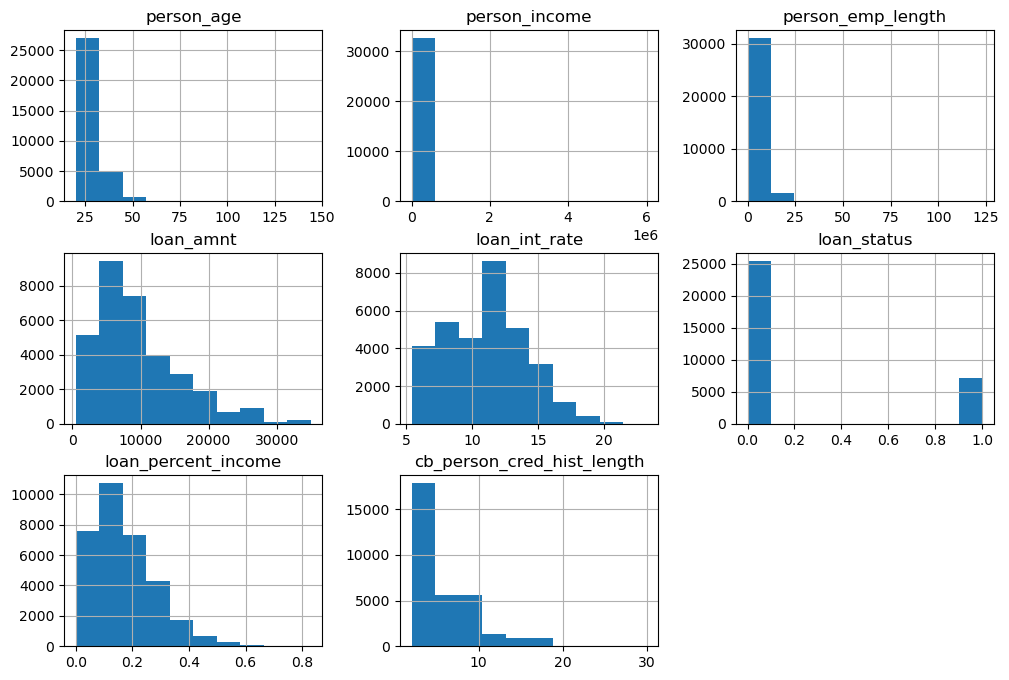

In [10]:
# р-л числових змінних

df.hist(figsize=(12, 8))

In [11]:
# викиди в колонці person_income з допомогою [Interquartile range]

Q1 = df["person_income"].quantile(0.25)
Q3 = df["person_income"].quantile(0.75)
IQR = Q3 - Q1

# межі
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

# відкидаєм що поза ними
df = df[(df["person_income"] >= lower)
        & (df["person_income"] <= upper)]

# що лиишилось
print(f"Після фільтрації в межі потрапляє {df.shape[0]} рядків")

Після фільтрації в межі потрапляє 31097 рядків


In [12]:
# які є категоріальні колонки
df.select_dtypes("object").columns

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')

In [13]:
# аналіз категоріальних змінних відносно цільової ("loan_status")
# частота зустрічання різних значень

categorical_columns  = ["person_home_ownership", "loan_intent", "loan_grade", "cb_person_default_on_file"]

for col in categorical_columns:
    print(f"\n{df[col].value_counts()}")



person_home_ownership
RENT        16102
MORTGAGE    12426
OWN          2469
OTHER         100
Name: count, dtype: int64

loan_intent
EDUCATION            6201
MEDICAL              5846
VENTURE              5445
PERSONAL             5260
DEBTCONSOLIDATION    4955
HOMEIMPROVEMENT      3390
Name: count, dtype: int64

loan_grade
A    10343
B     9924
C     6191
D     3459
E      899
F      221
G       60
Name: count, dtype: int64

cb_person_default_on_file
N    25626
Y     5471
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

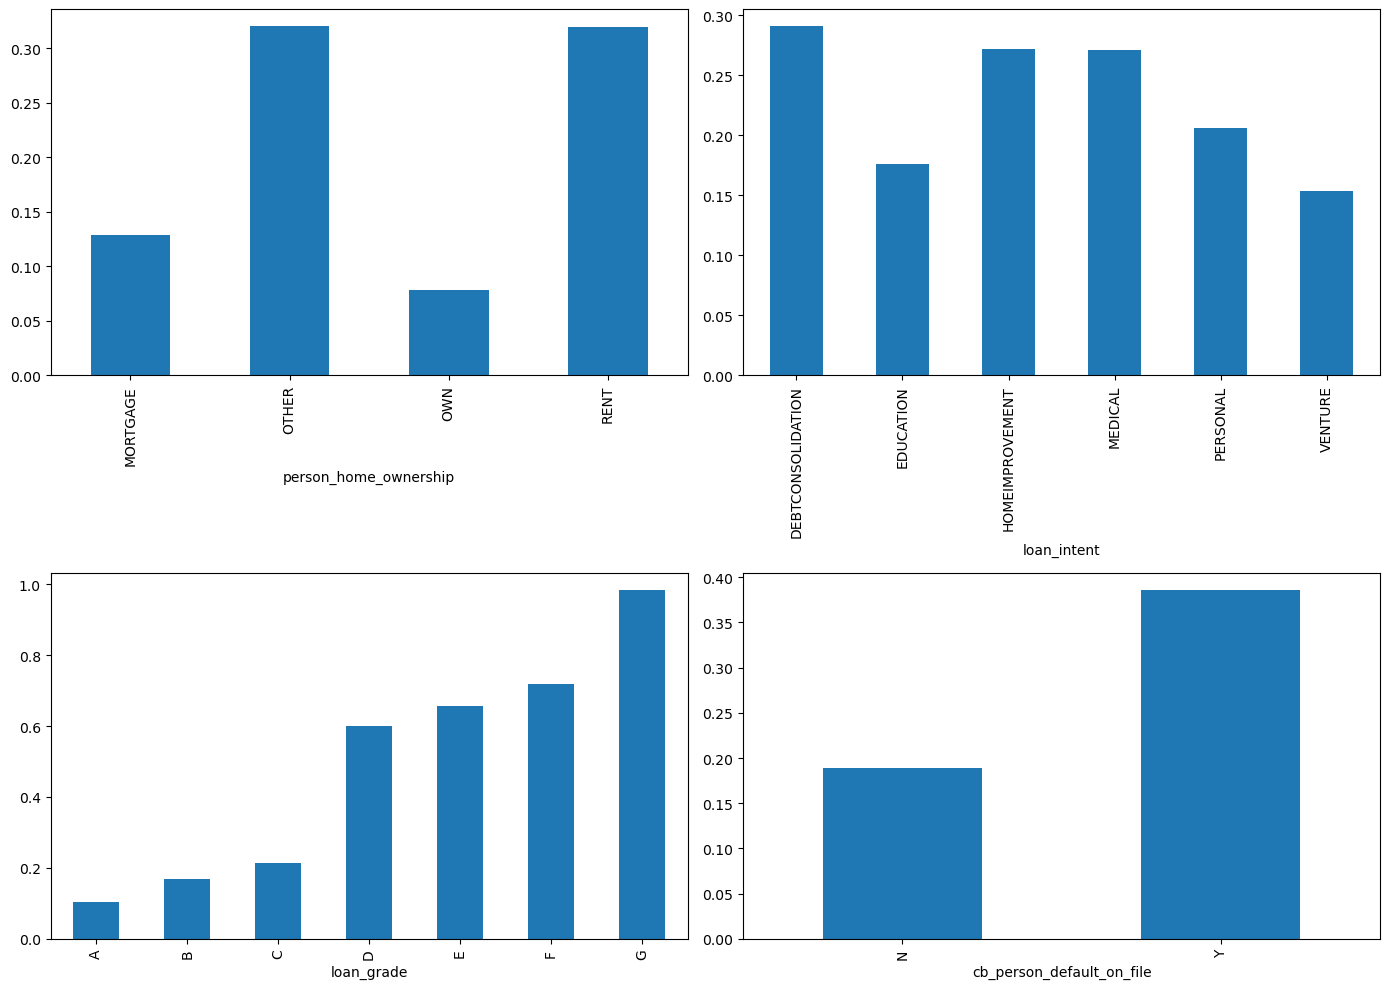

In [14]:
# Візуалізуйте взаємозв'язок ознак з цільовою змінною ("loan_status")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df.groupby("person_home_ownership")["loan_status"].mean().plot(kind="bar", ax=axes[0][0])
df.groupby("loan_intent")["loan_status"].mean().plot(kind="bar", ax=axes[0][1])
df.groupby("loan_grade")["loan_status"].mean().plot(kind="bar", ax=axes[1][0])
df.groupby("cb_person_default_on_file")["loan_status"].mean().plot(kind="bar", ax=axes[1][1])

plt.tight_layout()
plt.show


---

## Завдання 3: Аналіз кореляцій та Feature Engineering (3 бали)

**Що потрібно зробити:**
1. Побудуйте матрицю кореляцій для числових змінних.
2. Закодуйте категоріальні змінні.
3. Виберіть фінальний набір ознак, можна лишити всі, якщо ви вважаєте, що це - доцільно.



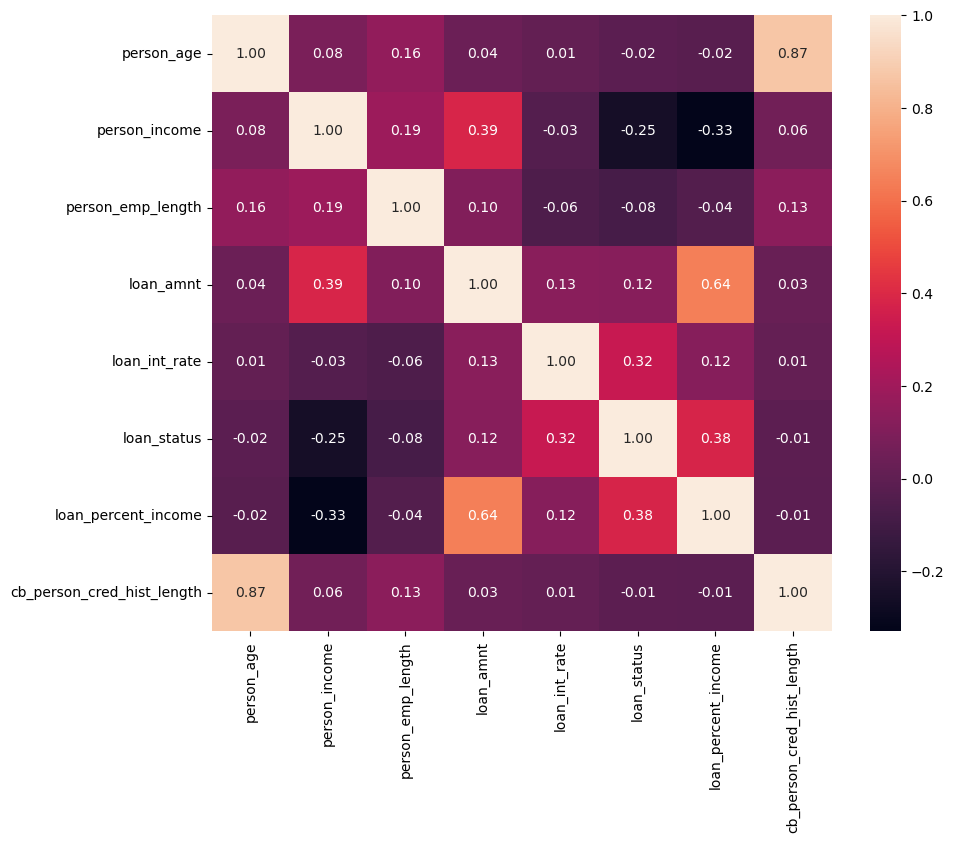

In [15]:
# матриця кореляцій для числових змінних

plt.figure (figsize=(10, 8))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, fmt=".2f")

plt.show()

З loan_status позитивна кореляція є у

0.38 loan_percent_income

0.32 loan_int_rate

0.13 loan_amnt


негативна  кореляція з

-0.26 person_income

-0.08 person_emp_length

-0.02 person_age

-0.01 cb_person_cred_hist_length

In [16]:
# кодування категоріальних змінних
# One-hot encoding

df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

df_encoded.shape

(31097, 23)

In [17]:
df_encoded.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True


In [18]:
# фінальний набір ознак
feature_columns = [col for col in df_encoded.columns  if col != "loan_status"]

# залишимо всі ознаки. оскільки жодна не має 0 кореляції з цільовою змінною


In [19]:
X = df_encoded[feature_columns]
y = df_encoded["loan_status"]

print(f"Кількість ознак: {X.shape[1]}")
print(f"Розмір вибірки: {X.shape[0]}")

Кількість ознак: 22
Розмір вибірки: 31097



---

## Завдання 4: Підготовка даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на X та y
2. Поділіть на навчальну та тестову вибірки
3. Застосуйте масштабування
4. Навчіть модель логістичної регресії
5. Зробіть прогнози на тренувальній та тестовій вибірках.



In [20]:
from sklearn.model_selection import train_test_split

In [21]:
# ділимо на навчальну і тестову вибірки

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} позичальників")
print(f"Test: {X_test.shape[0]} позичальників")
print(f"ймовірність дефолту за кредитом в train: {y_train.mean():.1%}")
print(f"ймовірність дефолту за кредитом в test: {y_test.mean():.1%}")

Train: 24877 позичальників
Test: 6220 позичальників
ймовірність дефолту за кредитом в train: 22.4%
ймовірність дефолту за кредитом в test: 22.4%


In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
# масштабуємо
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
from sklearn.linear_model import LogisticRegression

In [25]:
# логістична регресія
## Сигмоїда (логістична функція) перетворює будь-яке число на ймовірність

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Модель навчена!")

Модель навчена!


In [26]:
model


LogisticRegression(max_iter=1000, random_state=42)

In [27]:
# прогнози на тренувальній та тестовій вибірках

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)

In [28]:
y_pred_proba

array([[0.96857492, 0.03142508],
       [0.9864314 , 0.0135686 ],
       [0.96520606, 0.03479394],
       ...,
       [0.461498  , 0.538502  ],
       [0.92474778, 0.07525222],
       [0.99242734, 0.00757266]])

In [29]:
# поріг класифікації = каже "дефолт" якщо ймовірність > 0.6
# [:, 1] — ймовірність класу 1 (дефолт)

(y_pred_proba[:, 1]>0.6).astype(int)

array([0, 0, 0, ..., 0, 0, 0])

In [30]:
# прогноз для перших 5 позичальників

sample_predictions = pd.DataFrame({
    "реальний дефолт": y_test.values[:5],
    "прогнозований дефолт": y_pred[:5],
    "ймовірність сплати за кредитом": y_pred_proba[:5, 0].round(3),
    "ймовірність дефолту за кредитом": y_pred_proba[:5, 1].round(3)
})
print(sample_predictions)

   реальний дефолт  прогнозований дефолт  ймовірність сплати за кредитом  \
0                0                     0                           0.969   
1                0                     0                           0.986   
2                0                     0                           0.965   
3                0                     0                           0.966   
4                0                     1                           0.164   

   ймовірність дефолту за кредитом  
0                            0.031  
1                            0.014  
2                            0.035  
3                            0.034  
4                            0.836  



---

## Завдання 5: Оцінка якості моделі (4 бали)

**Що потрібно зробити:**
1. Побудуйте confusion matrix.
2. Обчисліть основні метрики (accuracy, precision, recall, f1).
3. Побудуйте ROC-криву та обчисліть AUC
4. Проаналізуйте важливість ознак.
5. Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.


In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [32]:
# Confusion Matrix (Матриця помилок)

# True Negative (TN) — правильно передбачили "залишиться"
# True Positive (TP) — правильно передбачили "піде"
# False Positive (FP) — помилково сказали "піде" (помилка I роду)
# False Negative (FN) — помилково сказали "залишиться" (помилка II роду)

<function matplotlib.pyplot.show(close=None, block=None)>

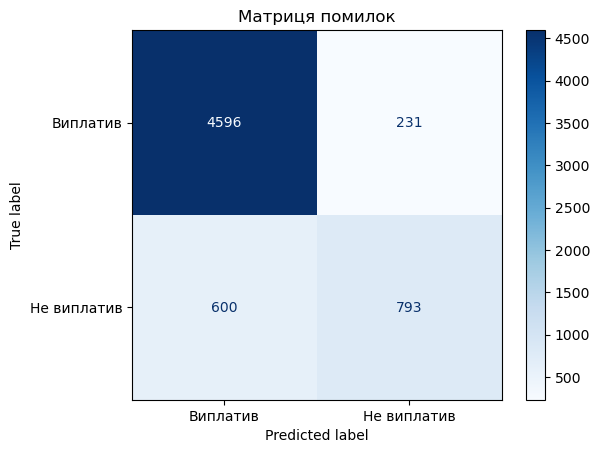

In [33]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Виплатив", "Не виплатив"])
disp.plot(cmap="Blues")
plt.title("Матриця помилок")
plt.show

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [35]:
# Accuracy = (TP + TN) / Всі прогнози
accuracy = accuracy_score(y_test, y_pred)

# Precision = TP / (TP + FP)
precision = precision_score(y_test, y_pred)

# Recall = TP / (TP + FN)
recall = recall_score(y_test, y_pred)

# F1-score = 2 × (Precision × Recall) / (Precision + Recall)
f1 = f1_score(y_test, y_pred)


print("МЕТРИКИ ЯКОСТІ МОДЕЛІ:")
print(f"Accuracy (Точність):    {accuracy:.3f}")
print(f"Precision (Влучність):  {precision:.3f}")
print(f"Recall (Повнота):       {recall:.3f}")
print(f"F1-score:               {f1:.3f}")

МЕТРИКИ ЯКОСТІ МОДЕЛІ:
Accuracy (Точність):    0.866
Precision (Влучність):  0.774
Recall (Повнота):       0.569
F1-score:               0.656


Позичальників в тесті: 4727

Правильно виявлено дефолт : 793

Пропущено: 600

Помилково: 231

In [36]:
from sklearn.metrics import roc_curve, roc_auc_score

In [37]:
# ROC-крива та AUC
# True Positive Rate (TPR) = TP / (TP + FN)
# False Positive Rate (FPR) = FP / (FP + TN)
## Ідеальна точка: TPR = 1 (виявляємо всіх) і FPR = 0 (без помилок) — верхній лівий кут графіка.

fpr, tpr, tresholds = roc_curve(y_test, y_pred_proba[:, 1])
auc = roc_auc_score(y_test, y_pred_proba[:, 1])

# віз
fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode="lines", name=f"ROC (AUC = {auc:.3f})"))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode="lines", line=dict(dash="dash"), name="Випадковий класифікатор"))

fig.update_layout(title="ROC-крива", xaxis_title ="False Positive Rate", yaxis_title = "True Positive Rate", height=500)
fig.show()

In [38]:
# Інтерпретація AUC:
# AUC = 0.5 — модель не краща за випадкове вгадування
# AUC = 0.7-0.8 — прийнятна модель
# AUC = 0.8-0.9 — хороша модель
# AUC > 0.9 — відмінна модель

Наша модель хороша!

In [39]:
# аналіз важливості ознак

# коефіцієнти моделі
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0],
    "abs_coefficient": np.abs(model.coef_[0])
}).sort_values("abs_coefficient", ascending=False)

feature_importance

,feature,coefficient,abs_coefficient
5,loan_percent_income,1.320734,1.320734
17,loan_grade_D,0.810887,0.810887
3,loan_amnt,-0.548753,0.548753
18,loan_grade_E,0.476109,0.476109
8,person_home_ownership_OWN,-0.458149,0.458149
9,person_home_ownership_RENT,0.404981,0.404981
14,loan_intent_VENTURE,-0.400907,0.400907
10,loan_intent_EDUCATION,-0.327289,0.327289
20,loan_grade_G,0.309605,0.309605
19,loan_grade_F,0.268611,0.268611


 Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.

Найбільшою є сила вплаиву таких ознак: 

loan_percent_income, loan_grade_D , loan_amnt,	loan_grade_E,	person_home_ownership_OWN.


Ризик збільшують наступні ознаки:

1.32    loan_percent_income - чим більша частка доходу йде на виплату кредиту, тим вищий ризик дефолту

0.81	loan_grade_D - чим нижчий кредитний рейтинг, тим вищий ризик дефолту

0.47	loan_grade_E - чим нижчий кредитний рейтинг, тим вищий ризик дефолту

0.40    person_home_ownership_RENT - орендоване житло збільшує ризик несплати кредити


Ризик зменшують:

-0.54	loan_amnt	- чим більший розмір позики, тим менший ризик дефолту

-0.45	person_home_ownership_OWN	- володіння нерухомістю, зменшує ризик дефолту

-0.40   loan_intent_VENTURE	 - інвестиційна мета позики зменшує ризик дефолту

-0.33	loan_intent_EDUCATION - позика на навчання зменшує ризик дефолту


Дивно виглядає, що loan_amnt зменшує ризик дефолту. Швидше за все, це про те, що великі розміри позик можливі
лише для надійних позичальників, тому ризики несплати зменшуються після певного порогу.


---

## Завдання 6: Оптимізація порогу та бізнес-аналіз (2 бали)

**Що потрібно зробити:**
1. Проаналізуйте метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5 різних порогів). Візуалізуйте як змінюються метрики якості при зміні порогу.
2. Оберіть оптимальний поріг для бізнес-задачі - можна обрати виходячи з попереднього пункту, або додати своїх роздумів і обрати інший.



In [40]:
#  метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5)

thresholds = np.arange(0.1, 0.9, 0.05)
metrics_by_threshold = []

for threshold in thresholds:
    y_pred_custom = (y_pred_proba[:, 1] >= threshold).astype(int)

    metrics_by_threshold.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred_custom),
        "recall": recall_score(y_test, y_pred_custom),
        "f1": f1_score(y_test, y_pred_custom)
    })

    metrics_df = pd.DataFrame(metrics_by_threshold)


In [41]:
# Візуалізуйте як змінюються метрики якості при зміні порогу

fig = px.line(
    metrics_df.melt(id_vars = "threshold"),
    x = "threshold",
    y = "value",
    color = "variable",
    title = "Метрики при різних порогах рішення",
    labels = {"value": "Значення метрики", "threshold": "Поріг"}
)
fig.show()

In [42]:
# оптимальний поріг

metrics_df[metrics_df["threshold"].round(2) == 0.35]

,threshold,precision,recall,f1
5,0.35,0.676144,0.699928,0.687831


Як бачимо, оптимальним є поріг = 0.35

Саме таке значення оптимізує точність нашої моделі.

В цій точці досягається баланс між Precision (0.68) та Recall (0.70) - що підтверджується найвищим значенням f1 = 0.69.
Тобто модель правильно виявляє 70% реальних дефолтів і при цьому 68% її прогнозів дійсно є дефолтами.

Саме тут модель може не відмовити зайвий раз і не пропустити дефолт.

<function matplotlib.pyplot.show(close=None, block=None)>

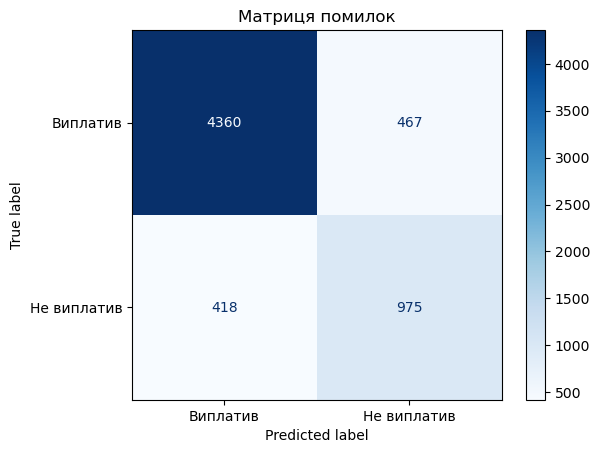

In [43]:
y_pred_opt = y_pred_proba[:, 1]>=0.35
cm = confusion_matrix(y_test, y_pred_opt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Виплатив", "Не виплатив"])
disp.plot(cmap="Blues")
plt.title("Матриця помилок")
plt.show

Порівняймо з тим, що мали при порозі 0.5:

Правильно виявлено дефолтів: 793

Пропущено: 600


При порозі 0.35:

Правильно виявлено: 975

Пропущено: 418

Тобто поріг 0.35 пропускає менше дефолтів (418 < 600) —  і це покращення!
Але є компроміс - тепер помилок на надійних клієнтах стало більше (467 > 231). Це баланс про який ми писали вище


---

## Завдання 7 (Опціональне): Покращення моделі та висновки (2 бали)

**Що потрібно зробити:**

На цих же даних навчіть DecisionTreeClassifier та RandomForestClassifier. Яка з трьох моделей дає найкращий результат на тестовому наборі?

Поріг класифікації можна для порівняння якостей моделей використовувати стандартний 0.5, або той, що ви виявили, як оптимальний на попередньому кроці.


In [44]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [45]:
# навчіть DecisionTreeClassifier та RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_pred_proba)
    })

results_df = pd.DataFrame(results).round(3)
print(results_df)


                 Model  Accuracy  Precision  Recall     f1    AUC
0  Logistic Regression     0.866      0.774   0.569  0.656  0.874
1        Decision Tree     0.903      0.957   0.595  0.734  0.872
2        Random Forest     0.929      0.959   0.714  0.818  0.930


Яка з трьох моделей дає найкращий результат на тестовому наборі?

За всіма показниками найкраще працює Random Forest.

AUC = 0.930

Accuracy = 0.93

Precision = 0.96

Recall = 0.71

f1 = 0.82


Random Forest найкраще розрізняє класи та найменше пропускає дефолти. А для банку пропущений дефолт є найдорожчою помилкою. 